<h1 style="text-align: center; color: white; background: #1E70E1; padding:10px;">
Livrable 4 : Modélisation numérique
</h1>

<h2 style="text-align: center; color: white; background: #50ADEA; padding:10px; padding-left: 0px; font-style: grease; text-decoration: underline;">
Introduction
</h2>

<h3 style="color: #1E70E1; padding:10px; padding-left: 0px; font-style: grease;">
Contextes
</h3>

<p style ="text-align: justify;">

- <p0 style="color: #50ADEA;">Contexte général :</p0><br>
Un agent est décédé car il s’est retrouvé isolé dans la base ennemie dans une salle de réunion, sans aucun moyen de communiquer avec l’extérieur. Le département de Recherche et Développement (R&D) a été sollicité pour trouver une solution pour remédier à ce genre de situation où la communication est bloquée.
- <p0 style="color: #50ADEA;">Contexte du livrable :</p0><br>
Ayant désormais la vision complète de la chaîne de transmission pour réaliser la communication, vous devez mettre en place un prototype pour faire la démonstration de la viabilité de votre solution.
</p>

<h3 style="color: #1E70E1; padding:10px; padding-left: 0px; font-style: grease;">
Problématique
</h3>

<p style ="text-align: justify;">
Comment réaliser l'envoi et la réception de notre signal numérique ?
</p>

<h3 style="color: #1E70E1; padding:10px; padding-left: 0px; font-style: grease;">
Table des matières
</h3>

<p style ="text-align: justify;">

- <p0 style="color: #50ADEA;">Chaîne de transmission</p0>
- <p0 style="color: #50ADEA;">Émission du message :</p0>
    - Conversion (Caractères vers Binaire)
    - Encodage en Manchester
    - Création de la trame
    - Modulations
- <p0 style="color: #50ADEA;">Réception du message :</p0>
    - Démodulations
    - Démantèlement de la trame
    - Décodage en Manchester
    - Conversion (Binaire vers Caractères)
</p>

<h3 style="padding:10px; padding-left: 0px; font-style: grease;">
Bibliothèques utilisées dans le programme
</h3>

In [48]:
# %pip install numpy
# %pip install matplotlib
# %pip install sounddevice

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd

<h2 style="text-align: center; color: white; background: #50ADEA; padding:10px; padding-left: 0px; font-style: grease; text-decoration: underline;"> 
Émission du message
</h2>

<p style ="text-align: justify;">

- Création du message
- Conversion (Caractères vers Binaire)
- Encodage de Manchester
- Création de la trame :
    - Ajout du CRC
    - Ajout des fanions
- <u>Émission du message modulé de 2 manières différentes :</u>
    - Avec une modulation ASK
    - Avec une modulation FSK
- Diffusion du message (son)
</p>

<h3 style="color: #1E70E1; padding:10px; padding-left: 0px; font-style: grease;">
Création du message
</h3>

In [50]:
Message = input("Entrez votre message :")

<h3 style="color: #1E70E1; padding:10px; padding-left: 0px; font-style: grease;">
Conversion (Caractère vers Binaire)
</h3>

In [51]:
Message_Decimale = []
Message_Caractere_Binaire = []

for Compteur_C_B in Message:
    Decimale_0 = ord(Compteur_C_B)
    Message_Decimale.append(Decimale_0)
    if Decimale_0 < 64:
        Ajout_Bit = '00' + bin(Decimale_0)[2:]
    else:
        Ajout_Bit = '0' + bin(Decimale_0)[2:]
    Message_Caractere_Binaire.extend([int(Bit) for Bit in Ajout_Bit])

print("Le message en décimale est :", Message_Decimale)
print("Le message en binaire est :", Message_Caractere_Binaire)

Le message en décimale est : [72, 101, 108, 112, 32, 77, 101, 32, 32, 67, 69, 83, 73]
Le message en binaire est : [0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1]


<h3 style="color: #1E70E1; padding:10px; padding-left: 0px; font-style: grease;">
Encodage en Manchester
</h3>

In [52]:
Message_Manchester = []

for Compteur_EM in Message_Caractere_Binaire:
    if Compteur_EM == 1:
        Message_Manchester.append(1)
        Message_Manchester.append(0)
    else:
        Message_Manchester.append(0)
        Message_Manchester.append(1)

print("Le message en binaire codé avec Manchester est :", Message_Manchester)

Le message en binaire codé avec Manchester est : [0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0]


<h3 style="color: #1E70E1; padding:10px; padding-left: 0px; font-style: grease;">
<u>Création de la trame :</u>

- Ajout du CRC
</h3>

<p style ="text-align: justify;">
Grâce au CRC, nous pourrons détecter si il y a une erreur lors de la réception du message.
</p>

In [53]:
def Division(Dividende, Diviseur):
    Dividende = list(Dividende)
    Diviseur = list(Diviseur)

    # Déroulement de la division euclidienne
    for Compteur_1 in range(len(Dividende) - len(Diviseur) + 1):
        # Si le bit actuel est 1, effectuer la division modulo 2
        if Dividende[Compteur_1] == '1':
            for Compteur_2 in range(len(Diviseur)):
                Dividende[Compteur_1 + Compteur_2] = str(int(Dividende[Compteur_1 + Compteur_2]) ** int(Diviseur[Compteur_2]))

    Reste = ''.join(Dividende[-(len(Diviseur)-1):])
    return Reste

Clee_CRC = '1011'
Message_Manchester_Copie = ''.join([str(Compteur) for Compteur in Message_Manchester])
Bits_CRC = Division(Message_Manchester_Copie + '000', Clee_CRC)
Message_CRC = Message_Manchester_Copie + Bits_CRC

print("Données CRC à envoyer :", Message_CRC)

Données CRC à envoyer : 0110010110010101011010010110011001101001101001010110101001010101010110010101010101100101101001100110100101100110010110010101010101011001010101010110010101011010011001010110011001100110010110100110010110010110100


<h3 style="color: #1E70E1; padding:10px; padding-left: 0px; font-style: grease;">

- Ajout des fanions
</h3>

In [54]:
Fanion = '10000001'

Trame = Fanion + Message_CRC + Fanion
Message_Fanion = list(Trame)

for Compteur_Fanion in range(0, len(Message_Fanion)):
    Message_Fanion[Compteur_Fanion] = int(Message_Fanion[Compteur_Fanion])

print("Données CRC à envoyer :", Message_Fanion)

Données CRC à envoyer : [1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1]


<h3 style="padding:10px; padding-left: 0px; font-style: grease;">
Constantes utilisées lors des modulations
</h3>

In [55]:
Message = Message_Fanion

Fe = 44100   # Fréquence d'échantillonnage
baud = 300   # Débit souhaité sur le canal de transmission exprimé en bits/s
Nbits = len(Message)   # Nombre initial de bits (taille du message Message_Manchester)
Ns = int(Fe / baud)    # Nombre de symboles par bit (Fréq d'échantillonnage / Débit binaire) 
N = int(Nbits * Ns)    # Nombre total de bits à moduler (Nombre de symboles par bit * Nombre de bits)

t = np.linspace (0.0, N / Fe, N)   # Vecteur temps
Message_Copie = np.repeat(Message, Ns)

<h3 style="color: #1E70E1; padding:10px; padding-left: 0px; font-style: grease;">
<u>Émission du message modulé de 2 manières différentes :</u>

- Avec une modulation ASK
</h3>

<p style ="text-align: justify;">
Nous allons envoyer le message une première fois, en utilisant uniquement une modulation ASK.</br>Une version complète du message nous est ensuite affichée graphiquement.
</p>

*****Affichage complet du message binaire avant et après sa modulation*****


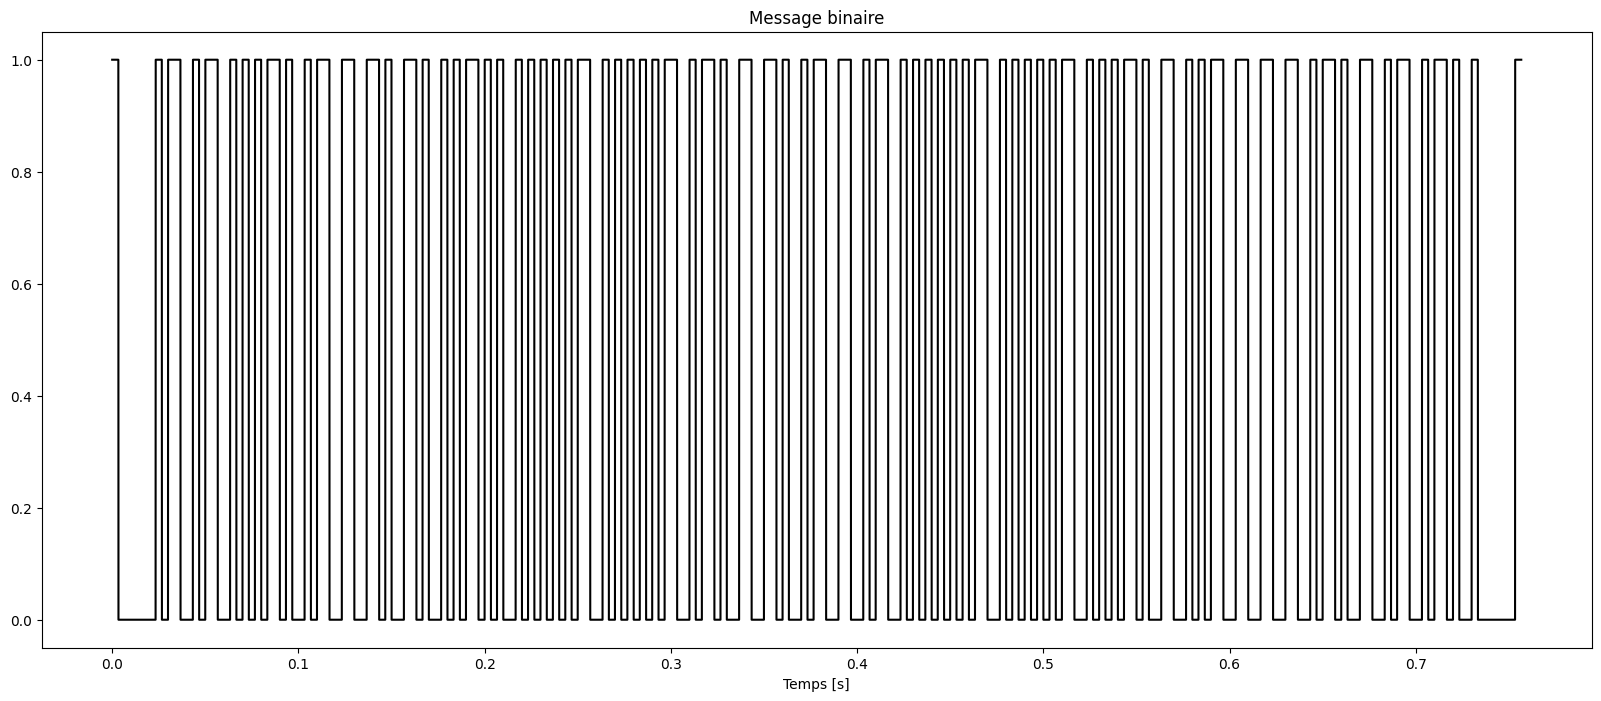

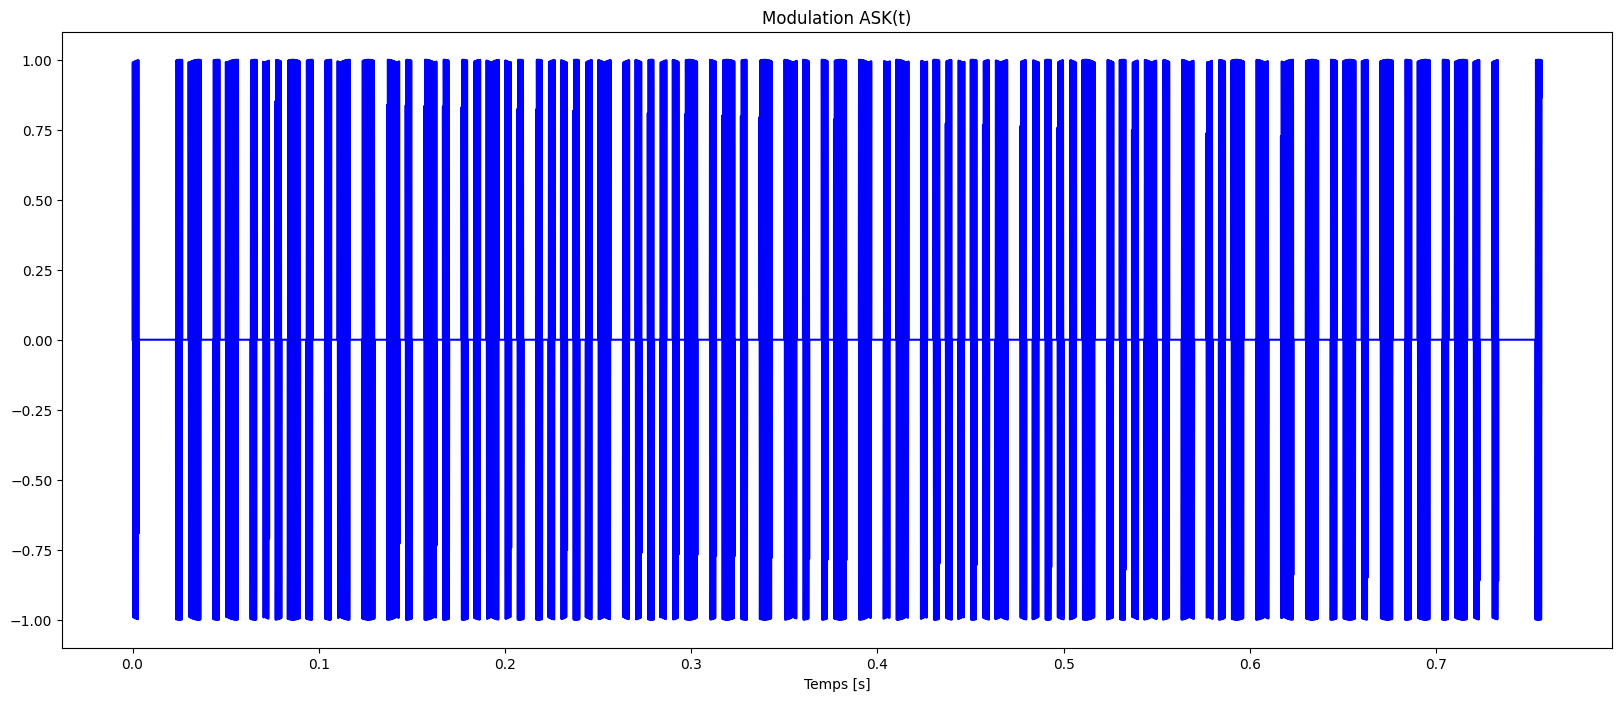

In [56]:
# On génère la porteuse
Ap = 1
Fp = 2000
Porteuse = Ap * np.sin(2 * np.pi * Fp * t)

ASK = Message_Copie * Porteuse

print("*****Affichage complet du message binaire avant et après sa modulation*****")

plt.figure(figsize = (20, 8))
plt.plot(t, Message_Copie, 'black')
plt.xlabel('Temps [s]')
plt.title('Message binaire')

plt.figure(figsize = (20, 8))
plt.plot(t, ASK, 'blue')
plt.xlabel('Temps [s]')
plt.title('Modulation ASK(t)')

plt.show()

<h3 style="color: #1E70E1; padding:10px; padding-left: 0px; font-style: grease;">

- Avec une modulation FSK
</h3>

<p style ="text-align: justify;">
Nous allons envoyer à nouveau le message, mais cette fois-ci avec une modulation FSK.</br>Une version complète du message nous est ensuite affichée graphiquement.
</p>

*****Affichage complet du message binaire avant et après sa modulation*****


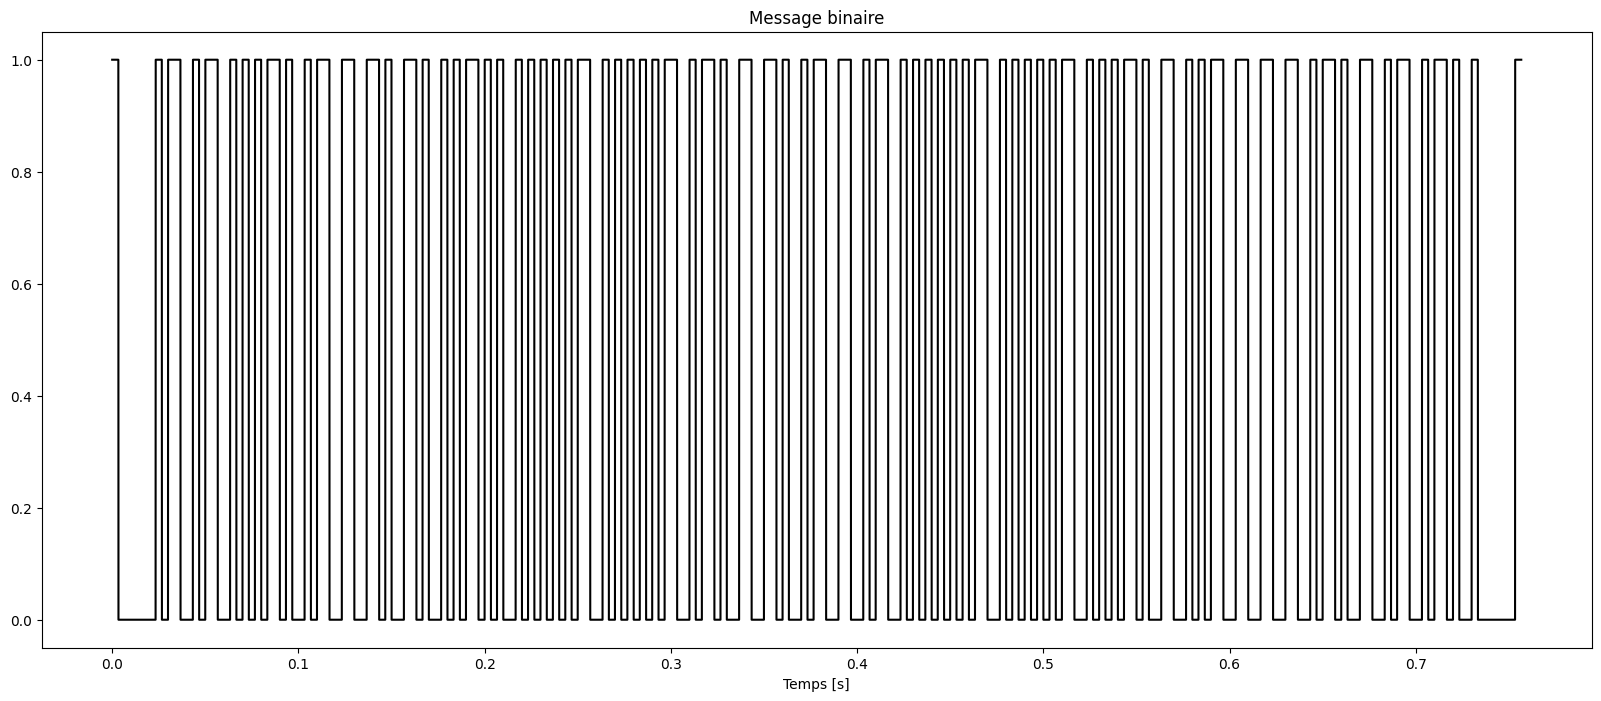

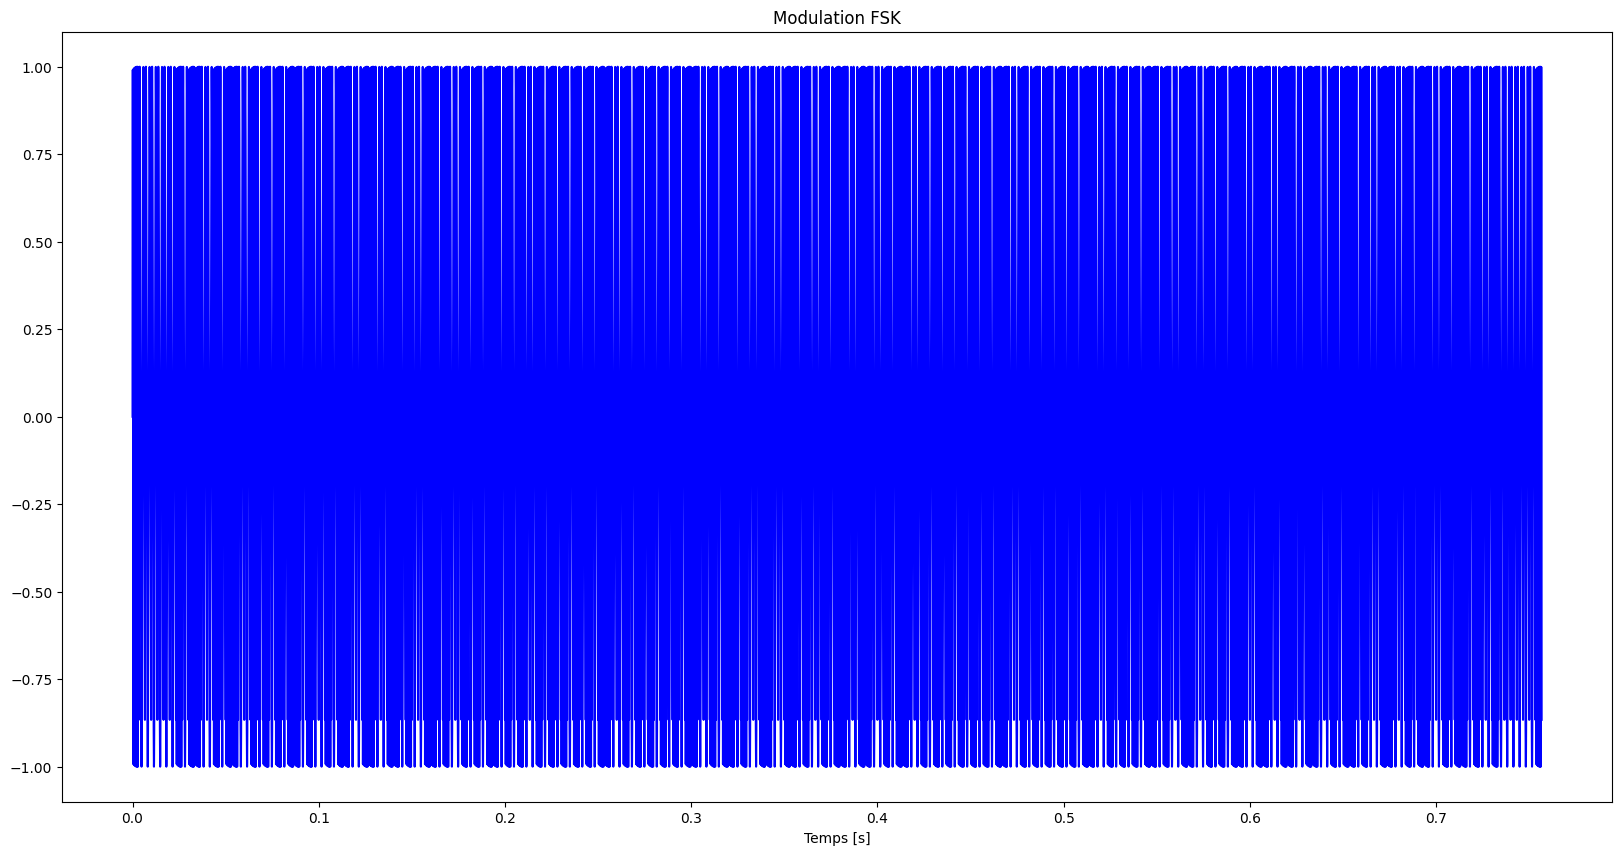

In [57]:
t1 = np.linspace (0.0, Ns / Fe, Ns)   # Vecteur temps pour FSK

# Génération des 2 porteuses (Porteuse_1 pour le bit 1 et Porteuse_2 pour le bit 0)
A1 = 1                           
A2 = 1
Fp1 = 500
Fp2 = 2000

Porteuse_1 = [A1 * np.sin(2 * np.pi * Fp1 * Compteur) for Compteur in t1]  
Porteuse_2 = [A2 * np.sin(2 * np.pi * Fp2 * Compteur) for Compteur in t1]

FSK = []

for Compteur_FSK_Modulation in Message:
    if Message[Compteur_FSK_Modulation] == 1:
        FSK.extend(Porteuse_1)
    else:
        FSK.extend(Porteuse_2)

print("*****Affichage complet du message binaire avant et après sa modulation*****")

plt.figure(figsize = (20, 8))
plt.plot(t, Message_Copie, 'black')
plt.xlabel('Temps [s]')
plt.title('Message binaire')

plt.figure(figsize = (20, 10))
plt.plot(t, FSK, 'blue')
plt.xlabel('Temps [s]')
plt.title('Modulation FSK')

plt.show()

<h3 style="padding:10px; padding-left: 0px; font-style: grease;">
Diffusion du message (son)
</h3>

In [66]:
sd.play(ASK, Fe)
sd.play(FSK, Fe)

<h2 style="text-align: center; color: white; background: #50ADEA; padding:10px; padding-left: 0px; font-style: grease; text-decoration: underline;">
Réception du message
</h2>

<p style ="text-align: justify;">

- <u>Réception du message modulé de 2 manières différentes :</u>
    - Avec une modulation FSK
    - Avec une modulation ASK
    - Comparaison des 2 messages après démodulation
- <u>Démantèlement de la trame :</u>
    - Vérification des fanions
    - Vérification du CRC
- Décodage de Manchester
- Conversion (Binaire vers Caractères)
</p>

<h3 style="color: #1E70E1; padding:10px; padding-left: 0px; font-style: grease;">
<u>Réception du message modulé de 2 manières différentes :</u>

- Avec une modulation FSK
</h3>

In [59]:
# On génère les 2 porteuses (pour les bits 1 et 0) Nbits fois à partir de des porteuses de base Porteuse_1 et Porteuse_2 avec la fonction python tile()
Porteuse_1 = np.tile(Porteuse_1, Nbits) 
Porteuse_2 = np.tile(Porteuse_2, Nbits)

Bit_1 = FSK * Porteuse_1
Bit_0 = FSK * Porteuse_2

# Intégration des 2 résultats Bit_1 et Bit_0 sur période de T = [0, Ns], Ns étant la taille du symbole envoyé par la méthode des trapèzes
Integration_Bit_1 = []
Integration_Bit_0 = []

for Compteur_4 in range(0, N, Ns):
    Integration_Bit_1.append(np.trapz(Bit_1[Compteur_4:Compteur_4 + Ns]))
    Integration_Bit_0.append(np.trapz(Bit_0[Compteur_4:Compteur_4 + Ns]))

<h3 style="color: #1E70E1; padding:10px; padding-left: 0px; font-style: grease;">

- Avec une modulation ASK
</h3>

In [60]:
t_ASK = np.arange(0.0,N)/Fe   # Vecteur temps

Produit = ASK * Porteuse

Res_ASK = []                         

for Compteur_ASK_Demodule in range(0,N,Ns):
  Res_ASK.append(np.trapz(Produit[Compteur_ASK_Demodule:Compteur_ASK_Demodule + Ns]))   # Réalisation de l'intégration

<h3 style="color: #1E70E1; padding:10px; padding-left: 0px; font-style: grease;">

- Comparaison des 2 messages après démodulation
</h3>

<p style ="text-align: justify;">
Cette étape sert à réaliser un test basique qui permet de savoir si les messages (similaires) envoyés deux fois avec une modulation différente à chaque fois (FSK, puis ASK) ont tous les deux étés reçus intacts en comparant le contenu des messages. Ainsi nous pouvons savoir si l'un des deux envois a vu ses données se faire corrompre.</br>Également, si à la fin du programme, le message reçu n'est pas le bon, cela signifie que le message qui s'est vu être envoyé deux fois a été corrompu aux deux envoient avec différentes modulations.
</p>

In [61]:
# Initialisation d'une liste pour stocker le message démodulé FSK
Message_FSK_Demodule = []

for Compteur_FSK_C in range(len(Integration_Bit_1)):
    if abs(Integration_Bit_1[Compteur_FSK_C]) > abs(Integration_Bit_0[Compteur_FSK_C]):
        Message_FSK_Demodule.extend([int(0)]) 
    if abs(Integration_Bit_1[Compteur_FSK_C]) <= abs(Integration_Bit_0[Compteur_FSK_C]):
        Message_FSK_Demodule.extend([int(1)])
        
# Initialisation d'une liste pour stocker le message démodulé ASK
Message_ASK_Demodule = []

for Compteur_ASK_C in range(len(Res_ASK)):
    if Res_ASK[Compteur_ASK_C] > 0:
        Message_ASK_Demodule.append(1)
    if Res_ASK[Compteur_ASK_C] == 0:
        Message_ASK_Demodule.append(0)

if Message_FSK_Demodule == Message_ASK_Demodule:
    Message_Recu_Demodule = Message_FSK_Demodule
    print("Les modulations FSK et ASK renvoient le même résultat :\n", Message_Recu_Demodule)
else:
    print("Les modulations FSK et ASK renvoient des résultats différents, il y a une erreur.")

Les modulations FSK et ASK renvoient le même résultat :
 [1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1]


<h3 style="color: #1E70E1; padding:10px; padding-left: 0px; font-style: grease;">
<u>Démantèlement de la trame :</u>

- Vérification des fanions
</h3>

In [62]:
Fanion_1 = []
Fanion_2 = []

# Reconstitution des fanions qui entourent le contenu de la trame
for Compteur_F1 in range (0, 8):
    Fanion_1.append(Message_Recu_Demodule[Compteur_F1])

for Compteur_F2 in range (-8, 0):
    Fanion_2.append(Message_Recu_Demodule[Compteur_F2])

Message_Complet = list(Message_Recu_Demodule)

# Suppression des fanions qui entourent le contenu de la trame
for Compteur_F1_Moins in range(0, 8):
    del Message_Complet[0]

for Compteur_F2_Moins in range(0, 8):
    del Message_Complet[-1]

print("La valeur du fanion 1 est :", Fanion_1)
print("La valeur du fanion 2 est :", Fanion_2)

if Fanion_1 == Fanion_2 :
    print("Il n'y a pas d'erreurs.")
    print("Le message sans les deux fanions est :", Message_Complet)
else : 
    print("Il y a une ou des erreurs !")

La valeur du fanion 1 est : [1, 0, 0, 0, 0, 0, 0, 1]
La valeur du fanion 2 est : [1, 0, 0, 0, 0, 0, 0, 1]
Il n'y a pas d'erreurs.
Le message sans les deux fanions est : [0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0]


<h3 style="color: #1E70E1; padding:10px; padding-left: 0px; font-style: grease;">

- Vérification du CRC
</h3>

In [63]:
Message_Recu_CRC_Copie = ''.join([str(Compteur) for Compteur in Message_Complet])
Message_Recu_CRC = Message_Complet[0:len(Message_Complet)-3]
CRC = int(''.join([str(Compteur) for Compteur in Message_Complet[-3:]]))

Reste = int(Division(Message_Recu_CRC_Copie, Clee_CRC))
Test = Reste - CRC

print("Valeur des bits CRC après soustraction:", Test)

if Test == 0:
    print("Aucunes des données transmises n'ont été perdue.")
else:
    print("Des pertes de données lors de la transmission ont été détecté !")

Valeur des bits CRC après soustraction: 0
Aucunes des données transmises n'ont été perdue.


<h3 style="color: #1E70E1; padding:10px; padding-left: 0px; font-style: grease;">
Décodage en Manchester
</h3>

In [64]:
Message_Recu_Manchester = Message_Recu_CRC
Message_Recu_Binaire = []

for i in range(round(len(Message_Recu_Manchester) / 2)):
    if Message_Recu_Manchester[2 * i] == 1 and Message_Recu_Manchester[2 * i + 1] == 0:
        Message_Recu_Binaire.append(1)
    if Message_Recu_Manchester[2 * i] == 0 and Message_Recu_Manchester[2 * i + 1] == 1:
        Message_Recu_Binaire.append(0)

print("Le message décodé en Manchester est :", Message_Recu_Binaire)

Le message décodé en Manchester est : [0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1]


<h3 style="color: #1E70E1; padding:10px; padding-left: 0px; font-style: grease;">
Conversion (Binaire vers Caractères)
</h3>

In [65]:
Message_Recu_Bin = ''
for Compteur_B_C in Message_Recu_Binaire:
    Message_Recu_Bin += str(Compteur_B_C)
    
Message_Recu = ''

def Binaire_Decimale(Bin):
    Decimale = 0
    Compteur = 0
    while Bin != 0: 
        Dec = Bin % 10
        Decimale = Decimale + Dec * pow(2, Compteur) 
        Bin = Bin // 10
        Compteur += 1
    return Decimale

for Compteur in range(0, len(Message_Recu_Bin), 8): 
    Variable = int(Message_Recu_Bin[Compteur + 1:Compteur + 8])
    Decimale = Binaire_Decimale(Variable)
    Message_Recu += chr(Decimale)

print("Le message que nous avons reçu est le suivant :", Message_Recu)

Le message que nous avons reçu est le suivant : Help Me  CESI


<h2 style='text-align: center; color: white; background: #50ADEA; padding:10px; padding-left: 0px; font-style: grease; text-decoration: underline;'>
Conclusion
</h2>

<p style ="text-align: justify;">
Grâce à la mise en oeuvre de deux types de modulation (ASK, FSK) de la même trame, qui est composée de 2 fanions (un de début et un de fin), ainsi que de données et d'une partie de 3 bits CRC. Avec les fanions de début et de fin nous vérifions notre transmission, avec la partie CRC nous vérifions que notre message a bien été transmis sans perte de données et nous pouvons ensuite passer notre partie donné en caractère et lire le message envoyé par l'agent.
</p>